In [1]:
#  Cell 1: Install extra packages 
!pip install -q scikit-learn
!pip install -q seaborn

print('All extra packages installed!')

All extra packages installed!


In [2]:
#  Cell 2: Import all required libraries 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import os, warnings
warnings.filterwarnings('ignore')

#  Detect device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use : {device}')
print(f'PyTorch version: {torch.__version__}')

Device in use : cuda
PyTorch version: 2.10.0+cu128


In [4]:
#  Cell 3: Define transforms for training and validation 

# TRAINING TRANSFORMS (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    transforms.RandomCrop(32, padding=4),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# VALIDATION / TEST TRANSFORMS (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Transforms defined successfully!')
print('  Training : resize + augmentation + normalize')
print('  Validation: resize + normalize only')

Transforms defined successfully!
  Training : resize + augmentation + normalize
  Validation: resize + normalize only


In [5]:
# ─── Cell 4: Download CIFAR-10 and create mini (5,000-image) subset ──

print('Downloading CIFAR-10 dataset (first run only — ~170 MB)...')

full_train_raw = datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=train_transform
)
full_test_raw  = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_transform
)

print(f'Full training set: {len(full_train_raw):,} images')
print(f'Full test set    : {len(full_test_raw):,} images')

# ── Helper: pick N images per class ──────────────────────────────────
import random
random.seed(42)

def make_balanced_subset(dataset, n_per_class=500, num_classes=10):
    targets = dataset.targets if hasattr(dataset, 'targets') else [y for _, y in dataset]

    indices_per_class = {c: [] for c in range(num_classes)}
    for idx, label in enumerate(targets):
        indices_per_class[label].append(idx)

    selected = []
    for c in range(num_classes):
        pool = indices_per_class[c]
        random.shuffle(pool)
        selected.extend(pool[:n_per_class])

    random.shuffle(selected)
    return Subset(dataset, selected)

# Create mini subsets
mini_train_full = make_balanced_subset(full_train_raw, n_per_class=500)
mini_test       = make_balanced_subset(full_test_raw,  n_per_class=100)

print(f'Mini training set: {len(mini_train_full)} images')
print(f'Mini test set    : {len(mini_test)} images')

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print(f'Classes: {class_names}')

100%|██████████| 170M/170M [00:02<00:00, 60.8MB/s] 


Full training set: 50,000 images
Full test set    : 10,000 images
Mini training set: 5000 images
Mini test set    : 1000 images
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
#  Cell 5: Split mini training set into train (80%) / val (20%)

train_size = int(0.8 * len(mini_train_full))   # = 4000
val_size   = len(mini_train_full) - train_size  # = 1000

train_dataset, val_dataset = random_split(
    mini_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = mini_test

print('Dataset split summary:')
print(f'  Training   : {len(train_dataset):>5} images  (80%)')
print(f'  Validation : {len(val_dataset):>5} images  (20%)')
print(f'  Test       : {len(test_dataset):>5} images  (held-out)')

Dataset split summary:
  Training   :  4000 images  (80%)
  Validation :  1000 images  (20%)
  Test       :  1000 images  (held-out)


In [9]:
#  Cell 6: Create DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'DataLoaders created  (batch size = {BATCH_SIZE})')
print(f'  Training batches  : {len(train_loader)}')
print(f'  Validation batches: {len(val_loader)}')
print(f'  Test batches      : {len(test_loader)}')

DataLoaders created  (batch size = 32)
  Training batches  : 125
  Validation batches: 32
  Test batches      : 32


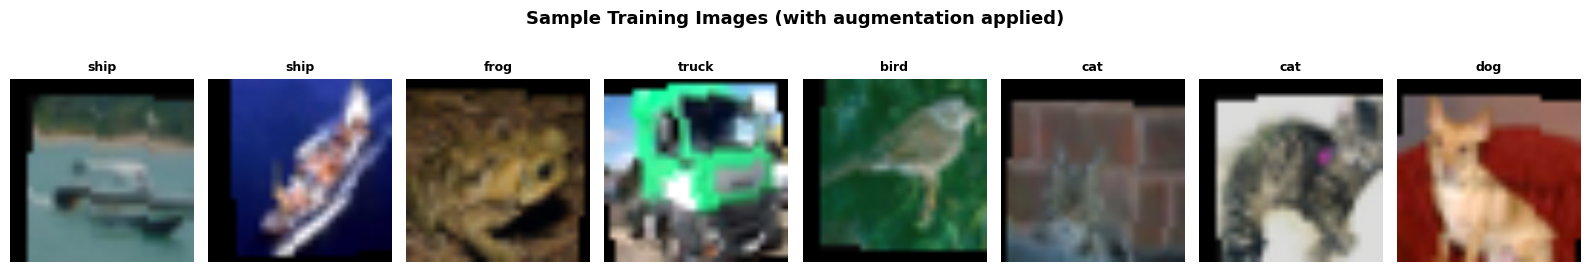

Notice: some images look slightly rotated or flipped — that is augmentation!


In [10]:
#  Cell 7: Display 8 sample training images 

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std) + mean

# Grab one batch from the training DataLoader
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(16, 3))

for i in range(8):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i].item()], fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Training Images (with augmentation applied)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice: some images look slightly rotated or flipped — that is augmentation!')

In [ ]:
# Why do we apply different transforms to training vs. validation data?

# Training data uses random augmentations (flip, rotate, colour jitter) to create 
# variety so the model learns general patterns, not memorised images — this prevents 
# overfitting. Validation data has no randomness so accuracy measurements are fair 
# and consistent every run.

In [11]:
#  Cell 8: Load pretrained ResNet18 and adapt for 10-class output 

# Load ResNet18 with ImageNet pretrained weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print('Original final layer (fc):', model.fc)

# Step 1: Freeze ALL pretrained layers 
for param in model.parameters():
    param.requires_grad = False

print('All pretrained layers frozen (weights locked).')

#  Step 2: Replace the final fully-connected layer 
NUM_CLASSES = 10
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

print(f'New final layer (fc)    : {model.fc}')

#  Step 3: Move model to GPU 
model = model.to(device)

#  Count parameters 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print(f'Trainable parameters : {trainable:>10,}  ({100*trainable/total:.2f}%)')
print(f'Frozen parameters    : {total-trainable:>10,}  ({100*(total-trainable)/total:.2f}%)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s] 

Original final layer (fc): Linear(in_features=512, out_features=1000, bias=True)
All pretrained layers frozen (weights locked).
New final layer (fc)    : Linear(in_features=512, out_features=10, bias=True)
Trainable parameters :      5,130  (0.05%)
Frozen parameters    : 11,176,512  (99.95%)


In [12]:
#  Cell 9: Configure the training components 

#  Loss Function 
criterion = nn.CrossEntropyLoss()

#  Optimiser 
optimizer = optim.Adam(
    model.fc.parameters(),   # only optimise the new classifier head
    lr=0.001
)

#  Learning Rate Scheduler 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print('Training components ready:')
print('  Loss function : CrossEntropyLoss')
print('  Optimiser     : Adam  (lr=0.001)')
print('  LR Scheduler  : ReduceLROnPlateau  (patience=2, factor=0.5)')

Training components ready:
  Loss function : CrossEntropyLoss
  Optimiser     : Adam  (lr=0.001)
  LR Scheduler  : ReduceLROnPlateau  (patience=2, factor=0.5)


In [ ]:
# Why do we pass model.fc.parameters() to the optimiser instead of model.parameters()?

# model.parameters() returns ALL parameters including frozen ones. 
# model.fc.parameters() returns only the new final layer's 5,130 parameters 
# the only ones we want to update. This avoids wasting computation on 
# frozen layers.



In [13]:
#  Cell 10: Define training and validation helper functions 

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, dim=1)
        total      += labels.size(0)
        correct    += (predicted == labels).sum().item()

        if batch_idx % 50 == 0:
            print(f'    Batch {batch_idx:3d}/{len(loader)} | Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            total      += labels.size(0)
            correct    += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

print('Training and evaluation functions defined!')

Training and evaluation functions defined!


In [14]:
#  Cell 11: Main training loop 

NUM_EPOCHS   = 10
best_val_acc = 0.0

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

print('=' * 60)
print('  STARTING TRAINING')
print(f'  Epochs: {NUM_EPOCHS}  |  Training batches per epoch: {len(train_loader)}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    print('-' * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_acc' ].append(train_acc)
    history['val_acc'   ].append(val_acc)

    print(f'  Train →  Loss: {train_loss:.4f}  |  Accuracy: {train_acc:.2f}%')
    print(f'  Val   →  Loss: {val_loss:.4f}  |  Accuracy: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'  NEW BEST MODEL saved!  Val Accuracy: {val_acc:.2f}%')

print('\n' + '=' * 60)
print('  TRAINING COMPLETE!')
print(f'  Best validation accuracy: {best_val_acc:.2f}%')
print('=' * 60)

  STARTING TRAINING
  Epochs: 10  |  Training batches per epoch: 125

Epoch 1/10
----------------------------------------
    Batch   0/125 | Loss: 2.3963
    Batch  50/125 | Loss: 1.9018
    Batch 100/125 | Loss: 1.5178
  Train →  Loss: 1.7455  |  Accuracy: 41.98%
  Val   →  Loss: 1.3220  |  Accuracy: 58.30%
  NEW BEST MODEL saved!  Val Accuracy: 58.30%

Epoch 2/10
----------------------------------------
    Batch   0/125 | Loss: 1.5341
    Batch  50/125 | Loss: 1.3465
    Batch 100/125 | Loss: 1.4273
  Train →  Loss: 1.2222  |  Accuracy: 60.77%
  Val   →  Loss: 1.0798  |  Accuracy: 65.20%
  NEW BEST MODEL saved!  Val Accuracy: 65.20%

Epoch 3/10
----------------------------------------
    Batch   0/125 | Loss: 1.1245
    Batch  50/125 | Loss: 1.4612
    Batch 100/125 | Loss: 1.2404
  Train →  Loss: 1.0822  |  Accuracy: 64.00%
  Val   →  Loss: 0.9906  |  Accuracy: 67.10%
  NEW BEST MODEL saved!  Val Accuracy: 67.10%

Epoch 4/10
----------------------------------------
    Batch   0/

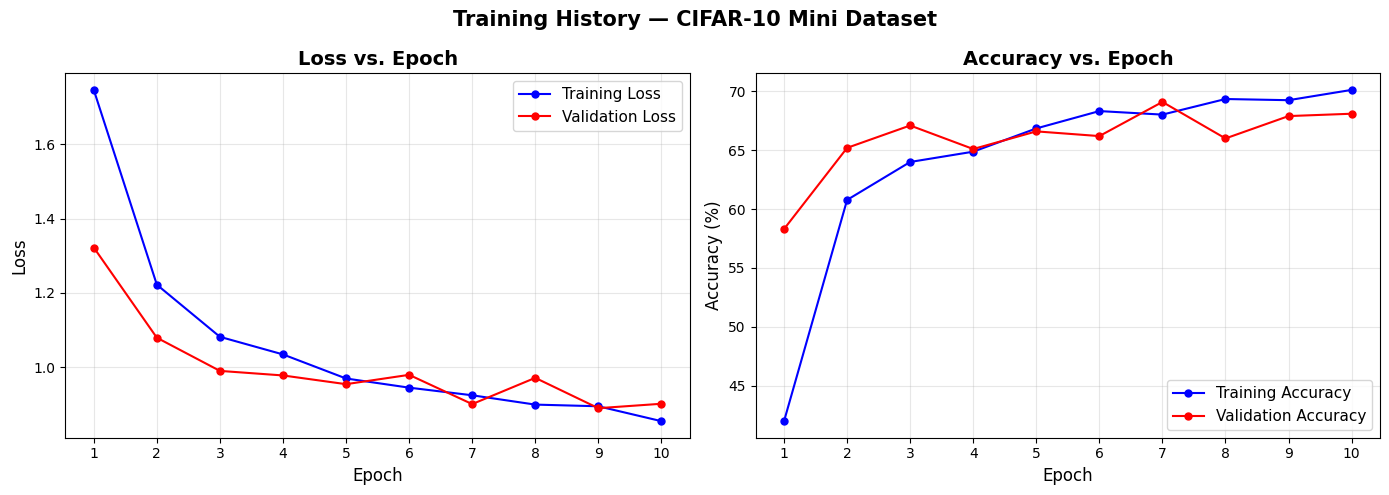

Good! Train-val gap is 2.0% -- model generalises well.


In [15]:
#  Cell 12: Plot loss and accuracy curves 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

#  Loss subplot 
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss',   markersize=5)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation Loss', markersize=5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss',  fontsize=12)
ax1.set_title('Loss vs. Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(epochs_range))

#  Accuracy subplot
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Training Accuracy',   markersize=5)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Validation Accuracy', markersize=5)
ax2.set_xlabel('Epoch',        fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy vs. Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(epochs_range))

plt.suptitle('Training History — CIFAR-10 Mini Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

#  Overfitting check 
final_gap = history['train_acc'][-1] - history['val_acc'][-1]

if final_gap > 15:
    print(f'WARNING: Large train-val gap ({final_gap:.1f}%) -- possible overfitting!')
    print('Fix: add more augmentation, or reduce learning rate.')
elif final_gap < -5:
    print(f'NOTE: Validation ({history["val_acc"][-1]:.1f}%) > Training ({history["train_acc"][-1]:.1f}%)')
    print('This can happen with strong augmentation -- usually fine.')
else:
    print(f'Good! Train-val gap is {final_gap:.1f}% -- model generalises well.')

In [17]:
#  Cell 13: Evaluate on the held-out test set 

model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

#  Overall accuracy 
test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

#  Per-class classification report 
print('\nClassification Report:')
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=3
))

Test Accuracy: 0.7530  (75.30%)

Classification Report:
              precision    recall  f1-score   support

    airplane      0.773     0.680     0.723       100
  automobile      0.744     0.870     0.802       100
        bird      0.636     0.750     0.688       100
         cat      0.678     0.610     0.642       100
        deer      0.847     0.610     0.709       100
         dog      0.777     0.730     0.753       100
        frog      0.724     0.920     0.811       100
       horse      0.811     0.770     0.790       100
        ship      0.744     0.900     0.814       100
       truck      0.885     0.690     0.775       100

    accuracy                          0.753      1000
   macro avg      0.762     0.753     0.751      1000
weighted avg      0.762     0.753     0.751      1000



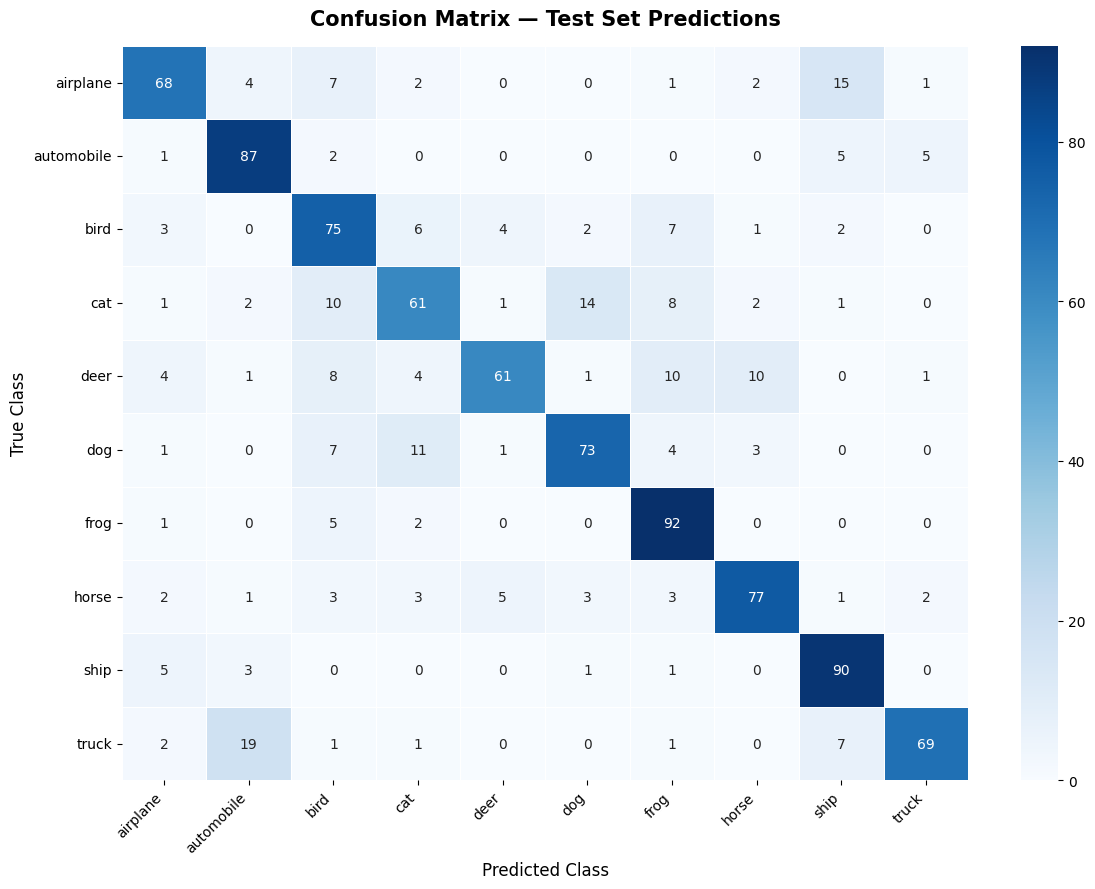

Most common mistake:
  True class  : truck
  Predicted as: automobile
  Times        : 19

Per-class accuracy:
  airplane     #############        68.0%
  automobile   #################    87.0%
  bird         ###############      75.0%
  cat          ############         61.0%
  deer         ############         61.0%
  dog          ##############       73.0%
  frog         ##################   92.0%
  horse        ###############      77.0%
  ship         ##################   90.0%
  truck        #############        69.0%


In [18]:
#  Cell 14: Confusion matrix visualisation 

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Confusion Matrix — Test Set Predictions', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class',      fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

#  Find the most confused pair 
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
worst   = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
print(f'Most common mistake:')
print(f'  True class  : {class_names[worst[0]]}')
print(f'  Predicted as: {class_names[worst[1]]}')
print(f'  Times        : {cm_copy[worst]}')

#  Per-class accuracy 
per_class = cm.diagonal() / cm.sum(axis=1)
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    bar = '#' * int(per_class[i] * 20)
    print(f'  {name:12s} {bar:<20} {per_class[i]:.1%}')

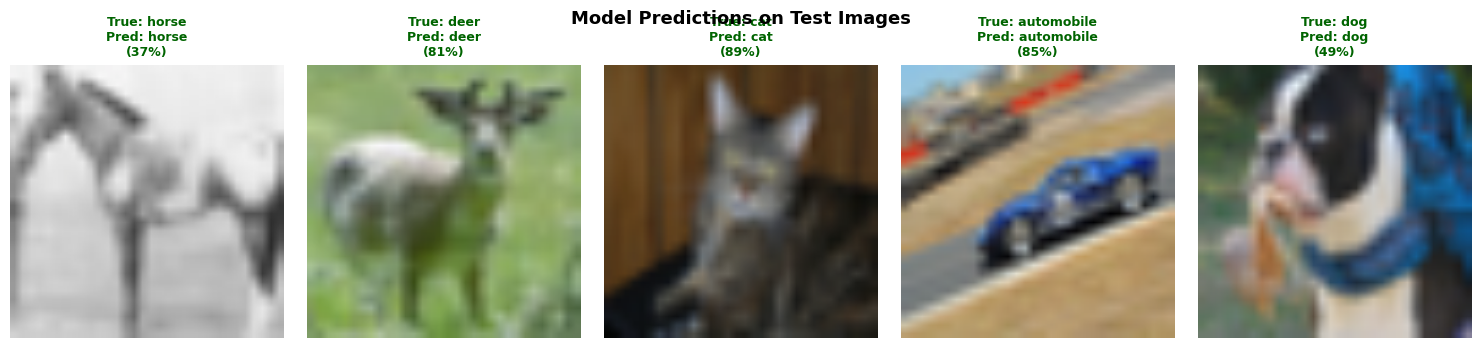

Green titles = correct  |  Red titles = incorrect


In [19]:
#  Cell 15: Show predictions on 5 test images side by side 

test_images, test_labels = next(iter(test_loader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))

model.eval()

for i in range(5):
    img_display = denormalize(test_images[i]).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    single_input = test_images[i].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(single_input)
        prob   = torch.nn.functional.softmax(output[0], dim=0)
        pred   = torch.argmax(prob).item()
        conf   = prob[pred].item()

    true_lbl = class_names[test_labels[i].item()]
    pred_lbl = class_names[pred]
    colour   = 'darkgreen' if pred == test_labels[i].item() else 'darkred'

    axes[i].imshow(img_display)
    axes[i].set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\n({conf:.0%})',
        fontsize=9, fontweight='bold', color=colour
    )
    axes[i].axis('off')

plt.suptitle('Model Predictions on Test Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Green titles = correct  |  Red titles = incorrect')

In [22]:
#  Cell 16: predict_image() — works on any JPG/PNG file 

def predict_image(image_path, model, class_names, device):
    #  Step 1: Load image 
    image = Image.open(image_path).convert('RGB')

    #  Step 2: Apply same preprocessing as validation 
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])

    #  Step 3: Prepare tensor 
    tensor = preprocess(image)
    tensor = tensor.unsqueeze(0)
    tensor = tensor.to(device)

    #  Step 4: Run inference 
    model.eval()
    with torch.no_grad():
        outputs = model(tensor)

    #  Step 5: Convert to probabilities 
    probs = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence, pred_idx = torch.max(probs, dim=0)
    predicted_class = class_names[pred_idx.item()]

    #  Step 6: Display image + top-5 bar chart 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(image)
    ax1.set_title(
        f'Predicted: {predicted_class.upper()}\nConfidence: {confidence.item():.1%}',
        fontsize=13, fontweight='bold', color='navy'
    )
    ax1.axis('off')

    top5_probs, top5_idx = torch.topk(probs, 5)
    top5_names  = [class_names[i.item()] for i in top5_idx]
    top5_values = [p.item() * 100 for p in top5_probs]

    colours = ['#1565C0' if i == 0 else '#90CAF9' for i in range(5)]
    ax2.barh(top5_names[::-1], top5_values[::-1], color=colours[::-1])
    ax2.set_xlabel('Confidence (%)', fontsize=11)
    ax2.set_title('Top 5 Predictions', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 100)

    for j, (val, name) in enumerate(zip(top5_values[::-1], top5_names[::-1])):
        ax2.text(val + 1, j, f'{val:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence.item()

print('predict_image() function defined and ready!')

predict_image() function defined and ready!


Saved sample image.  True class: horse


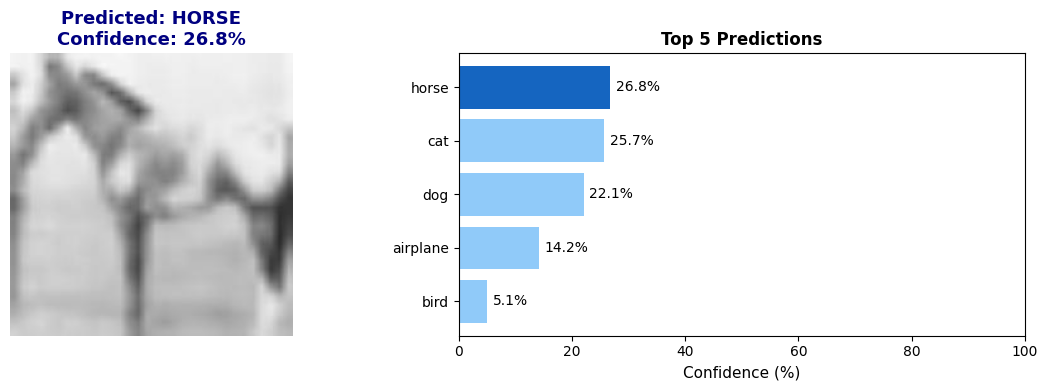

Predicted: horse  |  Confidence: 26.8%
✅ CORRECT prediction!


In [23]:
#  Cell 17: Test predict_image() using an image from the test set 

sample_img_tensor, sample_label = test_dataset[0]

# Denormalize and convert to PIL Image for saving
sample_pil = denormalize(sample_img_tensor).permute(1, 2, 0).numpy()
sample_pil = np.clip(sample_pil * 255, 0, 255).astype(np.uint8)
pil_img    = Image.fromarray(sample_pil)
pil_img.save('sample_test_image.jpg')

true_class = class_names[sample_label]
print(f'Saved sample image.  True class: {true_class}')

# Now run the inference function on it
pred, conf = predict_image('sample_test_image.jpg', model, class_names, device)
print(f'Predicted: {pred}  |  Confidence: {conf:.1%}')

if pred == true_class:
    print('✅ CORRECT prediction!')
else:
    print(f'❌ WRONG — true class was {true_class}')

In [25]:
#  Cell 18: Save a complete checkpoint and load it back 

#  Save a rich checkpoint 
checkpoint = {
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc'        : best_val_acc,
    'class_names'         : class_names,
    'num_classes'         : NUM_CLASSES,
    'architecture'        : 'resnet18',
    'training_history'    : history
}
torch.save(checkpoint, 'cifar10_mini_checkpoint.pth')
print('Checkpoint saved to cifar10_mini_checkpoint.pth')

#  Load the checkpoint and rebuild the model 
def load_checkpoint(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)

    loaded_model = models.resnet18(weights=None)
    loaded_model.fc = nn.Linear(
        loaded_model.fc.in_features,
        ckpt['num_classes']
    )

    loaded_model.load_state_dict(ckpt['model_state_dict'])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    print(f"Loaded model from {checkpoint_path}")
    print(f"Best validation accuracy: {ckpt['best_val_acc']:.2f}%")
    return loaded_model, ckpt['class_names']

# Verify the load works
reloaded_model, reloaded_classes = load_checkpoint('cifar10_mini_checkpoint.pth', device)
print(f'Classes: {reloaded_classes}')

Checkpoint saved to cifar10_mini_checkpoint.pth
Loaded model from cifar10_mini_checkpoint.pth
Best validation accuracy: 69.10%
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
